# Lab 6 — Morphological Image Processing
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers:
1. **Task 1** — Create a binary test image with shapes and noise (from manual)
2. **Task 2** — Define a structuring element (from manual)
3. **Assessment Task 1** — Apply erosion, dilation, opening, closing using the 5×5 square kernel
4. **Assessment Task 2** — Apply the same operations using a circular kernel
5. **Assessment Task 3** — Compare the results


## Setup — Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

---
## Theory — What is morphological processing?

**Morphology** operations modify images based on **shape and connectivity** rather than pixel intensities. They're typically applied to **binary images** (black & white), but extensions exist for grayscale.

### The two ingredients of every morphological operation

1. **The image** — a binary image where white (`255`) pixels are *foreground* (the object) and black (`0`) pixels are *background*.
2. **The structuring element** (also called *kernel* or *probe*) — a small shape (e.g., 3×3 square, 5×5 circle) that you slide across the image. It's like the "tool" that probes the image's shape.

Different kernel shapes produce different effects. Choosing the right kernel is half the battle in morphology.

### The four basic operations

| Operation | What it does | Formula | Effect on objects |
|---|---|---|---|
| **Erosion** | Shrinks objects | $A \ominus B$ | Removes thin parts and noise |
| **Dilation** | Grows objects | $A \oplus B$ | Fills gaps, thickens objects |
| **Opening** | Erosion then dilation | $A \circ B = (A \ominus B) \oplus B$ | Removes small noise but keeps overall size |
| **Closing** | Dilation then erosion | $A \bullet B = (A \oplus B) \ominus B$ | Fills small holes but keeps overall size |

### How to remember each one

- **Erosion eats away** at object edges → output is smaller.
- **Dilation expands** object edges → output is larger.
- **Opening = "open up" the gaps** between separated noise specks (removes noise without shrinking real objects).
- **Closing = "close up" small holes** inside objects (fills gaps without growing real objects).



---
## Task 1 — Create a Binary Image with Shapes and Noise

The lab provides this code to generate a synthetic test image with **4 shapes** and some random **salt noise**:
- A solid filled circle on the left
- A solid filled rectangle 
- A hollow (outline-only) circle
- A hollow rectangle
- Plus 1000 random scattered white pixels (noise)

This image is perfect for demonstrating morphological operations because:
- The **noise** will be removed by erosion or opening.
- We can clearly see how each operation affects each shape type.

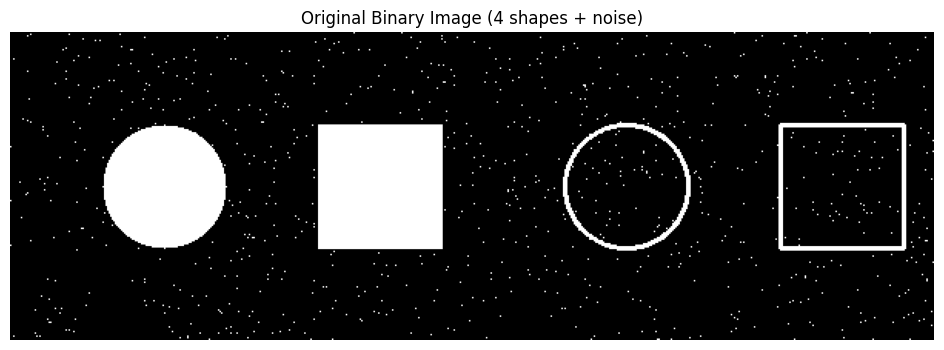

In [2]:
# --- Code from the lab manual ---
# Create a binary image with shapes and noise
image = np.zeros((200, 600), dtype=np.uint8)
cv2.circle(image, (100, 100), 40, 255, -1)              # Solid circle (filled)
cv2.rectangle(image, (200, 60), (280, 140), 255, -1)    # Solid rectangle (filled)
cv2.circle(image, (400, 100), 40, 255, 2)               # Hollow circle (outline)
cv2.rectangle(image, (500, 60), (580, 140), 255, 2)     # Hollow rectangle (outline)

# Add small noise (1000 random white pixels)
np.random.seed(0)
for _ in range(1000):
    x, y = np.random.randint(0, 600), np.random.randint(0, 200)
    image[y, x] = 255

plt.figure(figsize=(12, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Binary Image (4 shapes + noise)')
plt.axis('off')
plt.show()

**Notice the 4 shapes plus speckled noise.** That noise — the `255`s scattered around the background — will be our test for whether erosion/opening can clean it up.

---
## Task 2 — Define the Structuring Element (5×5 Square Kernel)

The structuring element is the "shape" we slide across the image. The simplest one is a **square of all ones**:

$$K = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \\ 1 & 1 & 1 & 1 & 1 \end{bmatrix}$$

**Why a square?** It's directionally neutral (same effect horizontally and vertically) and fast to compute. The `1`s indicate which positions in the neighborhood are "active" — for a square kernel, every neighbor counts.

In [3]:
# --- Code from the lab manual ---
kernel = np.ones((5, 5), np.uint8)
print("Square kernel (5×5):")
print(kernel)

Square kernel (5×5):
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


---
## Assessment Task 1 — Apply Erosion, Dilation, Opening, Closing (Square Kernel)

For each operation we use a single OpenCV function:

| Operation | OpenCV call |
|---|---|
| Erosion | `cv2.erode(image, kernel, iterations=1)` |
| Dilation | `cv2.dilate(image, kernel, iterations=1)` |
| Opening | `cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)` |
| Closing | `cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)` |



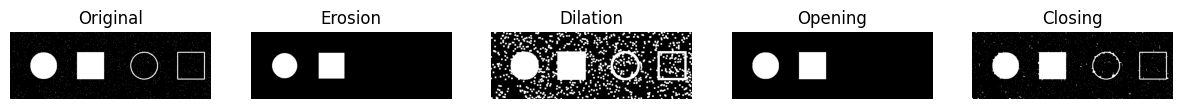

In [6]:
kernel = np.ones((5,5), np.uint8) # Square Kernel

erosion = cv2.erode(image, kernel, iterations=1) # Erosion

dilation = cv2.dilate(image, kernel, iterations=1) # Dilation

opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel) # Opening

closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel) # Closing

titles = ['Original', 'Erosion', 'Dilation', 'Opening', 'Closing'] # Display results
images = [image, erosion, dilation, opening, closing]

plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

## Assessment Task 2 — Repeat with a Circular Kernel

Because a square kernel **biases the result toward squareness** — it slightly distorts circular shapes into squarer ones. A circular kernel is **directionally neutral** and preserves the natural roundness of curved objects.

In [4]:
# --- Code from the lab manual ---
def circular_structuring_element(radius):
    """Creates a binary circular structuring element (exact circle)"""
    size = 2 * radius + 1                    # Ensure kernel size is odd
    kernel = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(kernel, (radius, radius), radius, 1, -1)  # Draw filled circle
    return kernel

# Define radius
radius = 5
circle_kernel = circular_structuring_element(radius)

print(f"Circular kernel (radius={radius}, size={circle_kernel.shape}):")
print(circle_kernel)

Circular kernel (radius=5, size=(11, 11)):
[[0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]]


## Assessment Task 3 — Difference Between Square vs Circular Kernel

 In your own words, explain the difference between the results in Task#1 and Task#2

The square kernel impacts the image more significantly at the corners and edges due to its rectangular form. This leads to erosion and dilation, resulting in more defined and block-like alterations in the objects. Conversely, the circular kernel generates softer and more organic results as it adheres to curved edges more effectively. It more effectively maintains rounded forms and diminishes sharp corner effects. Consequently, the outcomes in 

Task#1 with the square kernel looked more angular

Task#2 with the circular kernel seemed smoother and rounder.



---
## Summary Table

| Operation | OpenCV call | What it does | Use it to... |
|---|---|---|---|
| **Erosion** | `cv2.erode(...)` | Shrinks objects | Remove small bright noise, separate touching objects |
| **Dilation** | `cv2.dilate(...)` | Grows objects | Fill small gaps, connect nearby objects |
| **Opening** | `cv2.morphologyEx(..., MORPH_OPEN)` | Erosion → Dilation | **Remove small noise, keep object size** |
| **Closing** | `cv2.morphologyEx(..., MORPH_CLOSE)` | Dilation → Erosion | **Fill small holes, keep object size** |
| **Gradient** | `cv2.morphologyEx(..., MORPH_GRADIENT)` | Dilation − Erosion | Find object boundaries (edge map) |
| **Top-hat** | `cv2.morphologyEx(..., MORPH_TOPHAT)` | Image − Opening | Isolate small bright features |
| **Black-hat** | `cv2.morphologyEx(..., MORPH_BLACKHAT)` | Closing − Image | Isolate small dark features |

## Two big rules to remember

1. **Opening removes small bright things** (noise on a dark background).
2. **Closing fills small dark things** (holes inside a bright object).

Pick your **kernel shape** for what suits the geometry (square = fast, ellipse = round objects, cross = thin features). Pick your **kernel size** to be **larger than the noise** but **smaller than the real objects** you want to keep.

**End of notebook.**